# The Toy Universe: Interactive FTD

**"What I cannot create, I do not understand." — Richard Feynman**

Welcome to the FTD Sandbox. This notebook allows you to interact directly with the `ternary_matrix` physics engine. 

You can:
1.  **Modify Constants**: What happens if the Fine Structure Constant (ALPHA) is 0.1 instead of 0.007?
2.  **Break Physics**: Increase the speed of light (C) until the simulation explodes.
3.  **Witness Genesis**: Watch particles emerge from the void.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Add repository root to path
sys.path.append(os.path.abspath("../../"))

from ternary_matrix.model.grid import Universe
from ternary_matrix.physics import master_equation
from ternary_matrix.config import CONSTANTS

## 1. Configure Your Universe

Here are the controls. Change them and see what happens.

In [2]:
# === GOD MODE CONTROLS ===
CONSTANTS.C = 0.5           # Speed of Causality (Stability Limit: 0.577)
CONSTANTS.ALPHA = 0.00729   # Fine Structure Constant
CONSTANTS.KB = 1.0          # Manifestation Threshold
CONSTANTS.GRID_SIZE = 256    # Size of the universe (32x32x32)

print(f"Universe Configured:\n C={CONSTANTS.C}\n ALPHA={CONSTANTS.ALPHA}")

Universe Configured:
 C=0.5
 ALPHA=0.00729


## 2. The Big Bang (Initialization)

We create a vacuum with a small perturbation (a "Flux Pulse") in the center.

In [3]:
def big_bang():
    u = Universe(size=CONSTANTS.GRID_SIZE)
    center = u.size // 2
    
    # Inject energy (Flux)
    u.flux[center, center, center, 0] = 5.0  # X-flux pulse
    
    print("Bang! A universe is born.")
    return u

universe = big_bang()

Bang! A universe is born.


## 3. Run Simulation Loop

We simulate `N` timesteps. We'll track the total energy to check for stability.

DEBUG: No Genesis. Candidates: 7
DEBUG: No Genesis. Candidates: 1
DEBUG: No Genesis. Candidates: 6
DEBUG: No Genesis. Candidates: 1


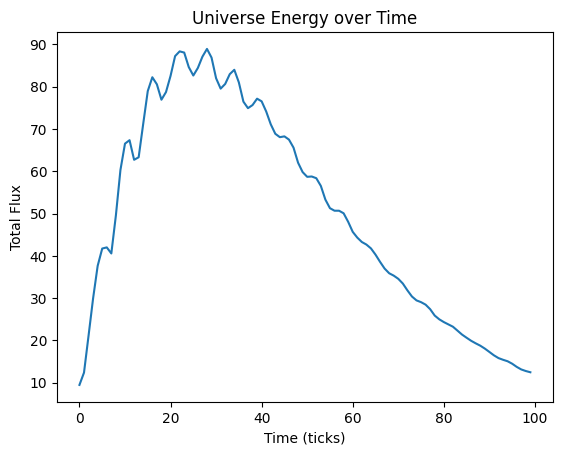

In [4]:
STEPS = 100
energy_history = []

for t in range(STEPS):
    master_equation.tick(universe)
    
    # Simple Energy metric (Flux magnitude)
    total_energy = np.sum(np.abs(universe.flux))
    energy_history.append(total_energy)

plt.plot(energy_history)
plt.title("Universe Energy over Time")
plt.xlabel("Time (ticks)")
plt.ylabel("Total Flux")
plt.show()

## 4. Visualizing the Fields

Let's look at a 2D slice of the 3D universe to see the waves propagating.

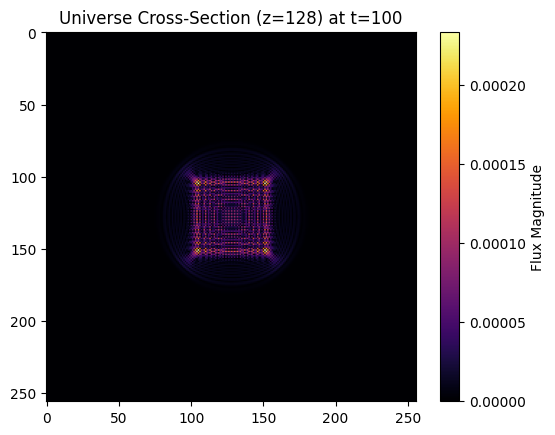

In [5]:
mid_z = universe.size // 2
slice_data = np.linalg.norm(universe.flux[:, :, mid_z, :], axis=-1)

plt.imshow(slice_data, cmap='inferno')
plt.colorbar(label="Flux Magnitude")
plt.title(f"Universe Cross-Section (z={mid_z}) at t={STEPS}")
plt.show()